In [693]:
import numpy as np
import pandas as pd
from skimpy import skim
from sklearn.preprocessing import LabelBinarizer, LabelEncoder

labelBinarizer = LabelBinarizer()
labelEncoder = LabelEncoder()

df = pd.read_csv('./studing/KalimentosFeirasVendas.csv')

In [694]:
df = df.convert_dtypes()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pedido_id                   3115 non-null   string 
 1   pedido_valor_total          3115 non-null   Float64
 2   pedido_data                 3115 non-null   string 
 3   pedido_tipo_desconto        3115 non-null   string 
 4   pedido_valor_desconto       3115 non-null   Float64
 5   pedido_subtotal             3115 non-null   Int64  
 6   pedido_vendedor             3115 non-null   string 
 7   pedido_metodo_pagamento     3115 non-null   string 
 8   item_pedido_nome_produto    3115 non-null   string 
 9   item_pedido_quantidade      3115 non-null   Int64  
 10  item_pedido_preco_unitario  3115 non-null   Float64
 11  item_pedido_user_id         3115 non-null   string 
 12  evento_nome                 3115 non-null   string 
dtypes: Float64(3), Int64(2), string(8)
memory us

In [695]:
# pedido_id
df['pedido_id'] = labelEncoder.fit_transform(df['pedido_id'])

# pedido_valor_total
df.rename(columns={'pedido_valor_total':'valor_final_pedido'}, inplace=True)

# pedido_data
df['pedido_data'] = pd.to_datetime(df['pedido_data'],format='mixed')

# pedido_tipo_desconto
"""
o tipo de desconto no fim não importa pois se executarmos o codigo abaixo vemos que nenhum item é retornado

df.query('pedido_valor_desconto != pedido_subtotal - valor_final_pedido')
"""
df = df.drop(['pedido_tipo_desconto'], axis=1)

# pedido_valor_desconto

# pedido_subtotal
df['pedido_subtotal'] = df['pedido_subtotal'].astype('Float64')

# pedido_vendedor
df.rename(columns={'pedido_vendedor':'vendedor'}, inplace=True)
df['vendedor'] = labelBinarizer.fit_transform(df['vendedor'])
df['vendedor'] = df['vendedor'].astype('category')

# pedido_metodo_pagamento
df.rename(columns={'pedido_metodo_pagamento': 'payment_mathod'}, inplace=True)
# df['payment_mathod'] = labelEncoder.fit_transform(df['payment_mathod'])
df['payment_mathod'] = df['payment_mathod'].astype('category')

# item_pedido_nome_produto
df.rename(columns={'item_pedido_nome_produto': 'nome_produto'}, inplace=True)
df['nome_produto'] = df['nome_produto'].astype('category')

#

df['evento_nome'] = df['evento_nome'].str.replace(' ', '_').str.upper()
df['evento_nome'] = df['evento_nome'].astype('category')

df['qtd_diff_prod'] =  df['pedido_id'].value_counts()
df['qtd_diff_prod'] = df['qtd_diff_prod'].astype('category')


# item_pedido_user_id
"""
Campo duplicado ao id do vendedor
"""
df = df.drop(['item_pedido_user_id'], axis=1)



In [696]:


df['nome_produto'] = df['nome_produto'].str.strip(" ")
df['nome_produto'] = df['nome_produto'].str.replace(' ', '_').str.upper()

df['nome_produto'] = df['nome_produto'].replace({
    'AMENDOIM_SALGADO_E_TEMPERADO':'AMENDOIM_TEMPERADO',
    'AMENDOIM_TEMPERADO_100G':'AMENDOIM_TEMPERADO',
    'RAPADURA_ASSADA_(PACOTE_X6)':'RAPADURA_ASSADA',
    'RAPADURA_ASSADA_(CAIXA_X20)':'RAPADURA_ASSADA',
    'RAPADURA_DE_MELADO':'RAPADURA_MELADO',
    'RAPADURA_DE_MELADO_(PACOTE_X3)':'RAPADURA_MELADO',
    'RAPADURA_DE_MELADO_GRÃO_MOÍDO':'RAPADURA_MELADO',
    'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X1)':'RAPADURA_MELADO',
    'ALFAJOR_PRETO_(DISPLAY_X1)':'ALFAJOR',
    'ALFAJOR_PRETO_(PACOTE_X4)':'ALFAJOR',
    'ALFAJOR_PRETO_(BANDEJA_X5)':'ALFAJOR',
    'ALFAJOR_PRETO_(CAIXA_X16)':'ALFAJOR',
    'ALFAJOR_PRETO_(DISPLAY_X16)':'ALFAJOR',
    'ALFAJOR_BRANCO_(DISPLAY_X1)':'ALFAJOR',
    'ALFAJOR_BRANCO_(PACOTE_X4)':'ALFAJOR',
    'ALFAJOR_BRANCO_(BANDEJA_X5)':'ALFAJOR',
    'ALFAJOR_BRANCO_(CAIXA_X16)':'ALFAJOR',
    'ALFAJOR_BRANCO':'ALFAJOR',
    'ALFAJOR_PRETO':'ALFAJOR',
    'CUCA_ENROLADA_DE_AMENDOIM_(PACOTE_X2)':'CUCA_ENROLADA',
    'CUCA_ENROLADA_DE_AMENDOIM':'CUCA_ENROLADA',
    'CUCA_ENROLADA_DE_CHOCOLATE':'CUCA_ENROLADA',
    'BOLACHA_COBERTURA_CHOCOLATE':'BOLACHA',
    'BOLACHA_DE_MANTEIGA':'BOLACHA',
    'BOLACHA_DE_MILHO':'BOLACHA',
    'CRI-CRI_200G':'CRI-CRI',
    })

df[['nome_produto']].value_counts().sort_index()

nome_produto      
ALFAJOR               497
AMENDOIM_TEMPERADO    115
BOLACHA                88
CARRAPINHA             13
CRI-CRI               104
CUCA_ALEMÃ            788
CUCA_ENROLADA         487
PÉ-DE-MOLEQUE          36
RAPADURA_ASSADA       457
RAPADURA_MELADO       530
Name: count, dtype: int64

In [697]:
df.query('nome_produto == "Alfajor Branco (Display x1)"')
df.query('pedido_id == 2413')

,pedido_id,valor_final_pedido,pedido_data,pedido_valor_desconto,pedido_subtotal,vendedor,payment_mathod,nome_produto,item_pedido_quantidade,item_pedido_preco_unitario,evento_nome,qtd_diff_prod
2405,2413,1462.0,2026-08-03 21:31:37.652000-03:00,0.0,1462.0,0,Dinheiro,CUCA_ALEMÃ,23,25.0,WOLKSFEST_AGUDO,1.0
2406,2413,1462.0,2026-08-03 21:31:37.652000-03:00,0.0,1462.0,0,Dinheiro,ALFAJOR,97,5.0,WOLKSFEST_AGUDO,1.0
2407,2413,1462.0,2026-08-03 21:31:37.652000-03:00,0.0,1462.0,0,Dinheiro,ALFAJOR,67,5.0,WOLKSFEST_AGUDO,1.0
2408,2413,1462.0,2026-08-03 21:31:37.652000-03:00,0.0,1462.0,0,Dinheiro,RAPADURA_MELADO,9,6.666667,WOLKSFEST_AGUDO,2.0
2409,2413,1462.0,2026-08-03 21:31:37.652000-03:00,0.0,1462.0,0,Dinheiro,RAPADURA_MELADO,1,7.0,WOLKSFEST_AGUDO,1.0


In [698]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype                    
---  ------                      --------------  -----                    
 0   pedido_id                   3115 non-null   int64                    
 1   valor_final_pedido          3115 non-null   Float64                  
 2   pedido_data                 3115 non-null   datetime64[us, UTC-03:00]
 3   pedido_valor_desconto       3115 non-null   Float64                  
 4   pedido_subtotal             3115 non-null   Float64                  
 5   vendedor                    3115 non-null   category                 
 6   payment_mathod              3115 non-null   category                 
 7   nome_produto                3115 non-null   object                   
 8   item_pedido_quantidade      3115 non-null   Int64                    
 9   item_pedido_preco_unitario  3115 non-null   Float64                  
 10 

<Axes: xlabel='evento_nome'>

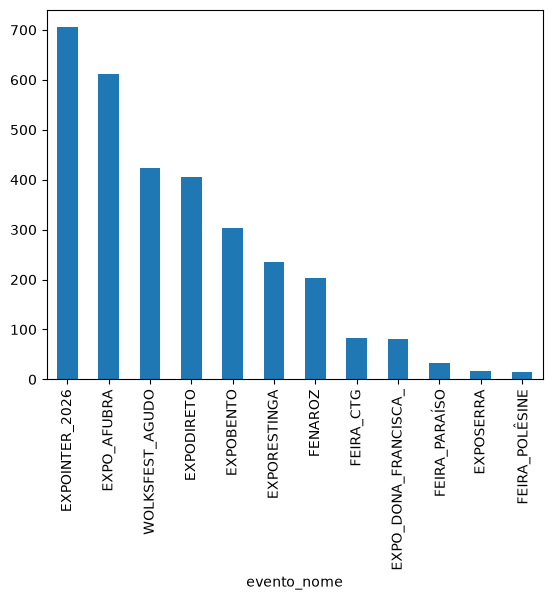

In [699]:
unicas = df['evento_nome'].value_counts()
unicas.plot(kind='bar')

In [700]:

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 3115   │ │ float64     │ 4     │ │ vendedor              │                                │
│ │ Number of columns │ 12     │ │ category    │ 4     │ │ payment_mathod        │                                │
│ └───────────────────┴────────┘ │ int64       │ 2     │ │ evento_nome           │                                │
│                                │ datetime64  │ 1     │ │ qtd_diff_prod         │                                │
│                                │ string      │ 1     │ └───────────────────────┘                                │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column                         ┃ NA  ┃ NA %  ┃ mean    ┃ sd     ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │           pedido_id            │   0 │     0 │    1231 │  710.8 │   0 │  610 │ 1230 │ 1848 │ 2456 │ ██████ │  │
│ │       valor_final_pedido       │   0 │     0 │   46.97 │  210.1 │   0 │   15 │   25 │   35 │ 3693 │   █    │  │
│ │     pedido_valor_desconto      │   0 │     0 │  0.3634 │  2.752 │   0 │    0 │    0 │    0 │   83 │   █    │  │
│ │        pedido_subtotal         │   0 │     0 │   47.33 │  210.4 │   5 │   15 │   25 │   35 │ 3696 │   █    │  │
│ │     item_pedido_quantidade     │   0 │     0 │   2.667 │  8.486 │   0 │    1 │    1 │    3 │  348 │   █    │  │
│ │   item_pedido_preco_unitario   │   0 │     0 │   13.29 │  8.654 │   4 │    6 │    8 │   25 │   80 │   █▄   │  │
│ └────────────────────────────────┴─────┴───────┴─────────┴────────┴─────┴──────┴──────┴──────┴──────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓  │
│ ┃ column                      ┃ NA      ┃ NA %                               ┃ ordered        ┃ unique       ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩  │
│ │          vendedor           │       0 │                                  0 │ False          │            2 │  │
│ │       payment_mathod        │       0 │                                  0 │ False          │            3 │  │
│ │         evento_nome         │       0 │                                  0 │ False          │           12 │  │
│ │        qtd_diff_prod        │     658 │                 21.123595505617978 │ False          │            7 │  │
│ └─────────────────────────────┴─────────┴────────────────────────────────────┴────────────────┴──────────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃ column        ┃ NA  ┃ NA %  ┃ first                          ┃ last                           ┃ frequency  ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━